<a href="https://colab.research.google.com/github/thoppae/kthoppae/blob/main/Model3_Retail_Prophet_launch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Read and preprocess your data
train_df = pd.read_csv('train.csv', low_memory=False)

train_df['Date'] = pd.to_datetime(train_df['Date'])

# Aggregate to daily totals if you have multiple entries per day
# Here assuming 'Sales' is already aggregated per day, otherwise groupby Date
prophet_df = train_df[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

In [ ]:
from prophet import Prophet

model = Prophet()
model.fit(prophet_df)

In [5]:
# Create a DataFrame holding the future dates to predict
future = model.make_future_dataframe(periods=30, freq='D')

# Run prediction
forecast = model.predict(future)

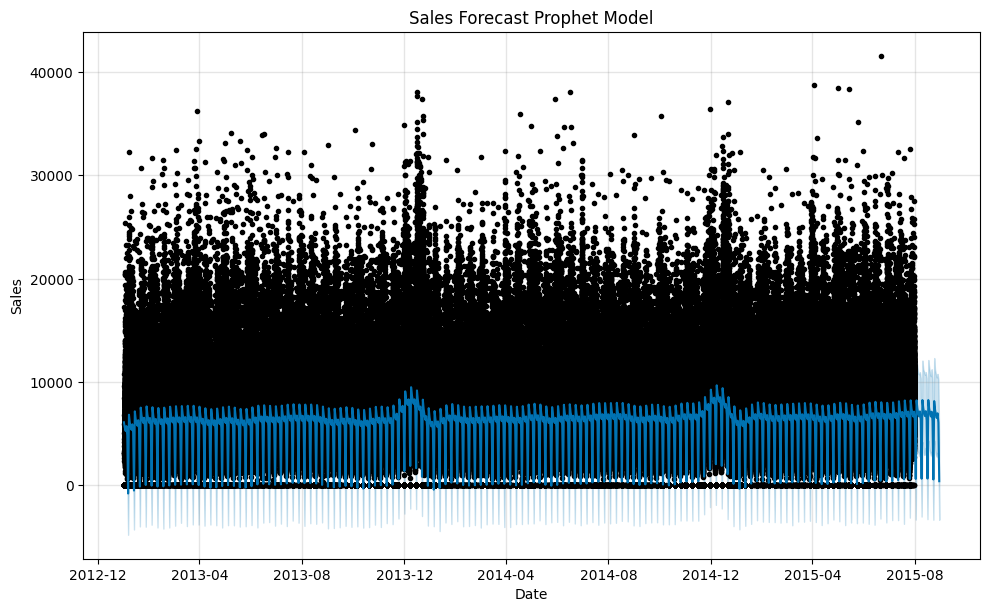

In [17]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)

plt.title("Sales Forecast Prophet Model")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

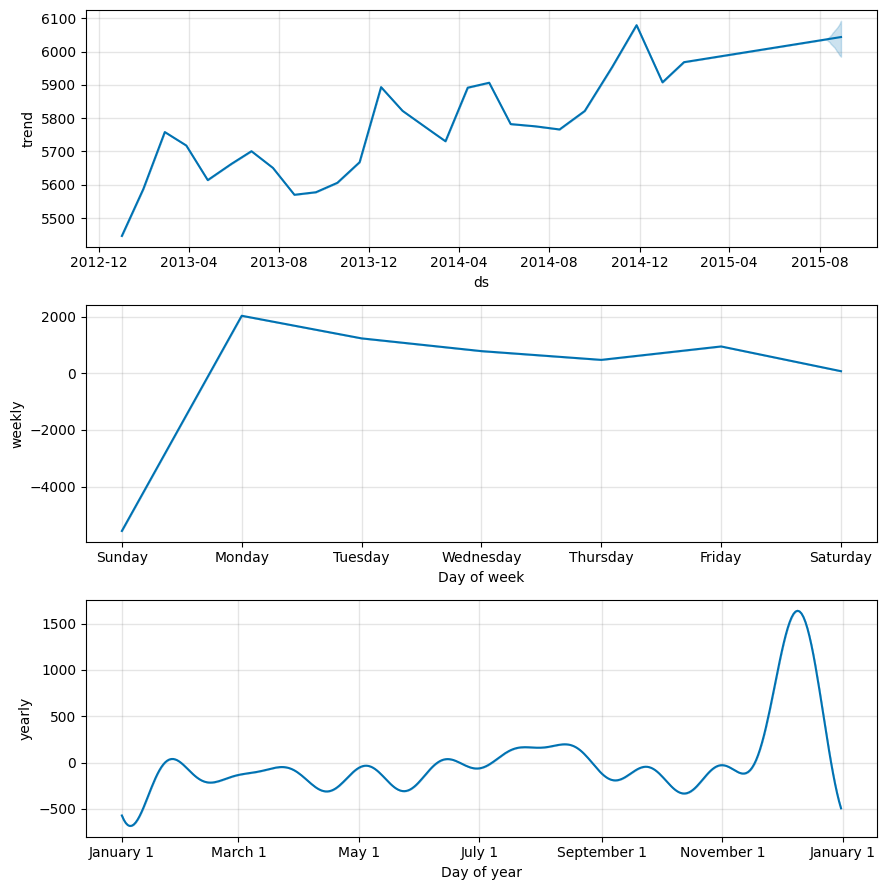

In [11]:
model.plot_components(forecast)
plt.show()